In [1]:
%%bash

pip install rasterio
pip install scikit-image
pip install pillow
pip install cmweather
pip install ipympl
pip install ipywidgets
wget -nc -q https://nimbus.niu.edu/courses/EAE483/BREF_090508_1300.png
wget -nc -q https://nimbus.niu.edu/courses/EAE483/000000274089.tif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.5 MB/s eta 0:00:00


# Chapter 9.2 - Image Segmentation

[Image segmentation](https://en.wikipedia.org/wiki/Digital_image_processing) describes approaches used in the identification of image regions or image objects. This process can be used to simplify or focus the analysis of images that often have very high-dimensionality. For example, CONUS-spanning, high-resolution geoscience datasets like [GridRad](https://gridrad.org/) and [Level II Radar Data](https://registry.opendata.aws/noaa-nexrad/), [MRMS](https://www.nssl.noaa.gov/projects/mrms/), and [GFS](https://registry.opendata.aws/noaa-gfs-bdp-pds/) can have hundreds of thousands or millions of "dimensions" in the form of pixels/grid points. While having the rich (i.e., tons of information) data available is a benefit for society, we often will use [data mining](https://en.wikipedia.org/wiki/Data_mining) techniques to reduce the dimensionality and make it easier to process. The vast majority of modern AI/ML tools perform either and explicit or implicit simplification step. For example, even though [convolutional neural networks](https://en.wikipedia.org/wiki/Convolutional_neural_network) and [large language models](https://en.wikipedia.org/wiki/Large_language_model) appear to ingest raw images and/or text, the ["black box"] portion of these models applies complex transformations to the data so that it is fit for ingesting into the model. Using the ingestion analogy, this is similar to how you can eat an apple and your body is able to break it down into its most important parts and get rid of the rest (luckily, this is not a biology class, so I do not have to go any further!).

### Chapter 9.2.1 - Image segmentation workflow

Basic image segmentation is largely based on empirical rules created by domain experts (i.e., [expert systems](https://en.wikipedia.org/wiki/Expert_system)). Segmentation algorithms take advantage two features in gridded Geoscience data: 1) grids have well-defined uniform spacing; and 2) grids have a well-defined and physically-derived intensity. With these two attributes, you can identify areas, shapes, distances, and other distinguishing features of regions and/or objects that might be found in gridded Geoscience datasets. For simple tasks, you might organize pixels into two categories:

1. `foreground` / `positive`: these pixels / grids belong to an object of interest.
2. `background` / `negative`: these pixels / grids do not belong to an object of interest.

A typical workflow looks something like this:

1. Identify a gridded dataset you would like to segment
2. Study the metadata, caveats, and assumptions
    - Projection: this might make distances, shapes, and areas more difficult to translate to "pixel space"
    - Intensity: if the intensity is reported in `mm` and you assume `in`, you could [experience a catastrophic error in your analysis.](https://en.wikipedia.org/wiki/Mars_Climate_Orbiter#Cause_of_failure)
    - Is the study period sufficient? Is the study area sufficient?
3. Create a high-level view of what it is you are trying to identify in the gridded data (either based on testing, literature, or both).
    - What are you actually trying to identify?
    - What are the features / attributes of this object?
    - How can you tell the difference between this object and the "background"
4. Translate the high-level view into "grid space".
    - What intensity value defines the edges of a region?
    - Does an object need a minimum area, length, maximum intensity, etc.?

## Chapter 9.2.2 - Thresholding

As we explored in a previous chapter, [image thresholding](https://en.wikipedia.org/wiki/Thresholding_(image_processing)) is the process of identifying pixels / grids that meet a certain criteria. Defining a threshold is extremely important for the segmentation process and this choice can dramatically change your analysis. This approach should be determined based on a solid understanding of the problem, as well as existing literature and/or best practices.

**Data Driven Thresholding**

You can automate the thresholding process by using an approach like [Otsu's Method](https://en.wikipedia.org/wiki/Otsu's_method). This method uses the histogram of image intensity values to determine the ideal threshold based on that image. Much like what we learned about how Decision Trees are created, this method tries to break the pixels into two different groups (`background` and `foreground`) based on a tested threshold. In this case, however, it tries to maximize the between-class variance, which depends on the the mean and the count of pixels above the threshold (i.e., all `foreground` pixels) and the mean of pixels below or equal to that threshold (i.e., all `background` pixels):


$\sigma_b^2 = w_0 w_1 (\mu_0 - \mu_1)^2$

where:

- $\sigma_b^2$ = between-class variance
- $w_0$ = proportion of pixels assigned to the background class
- $w_1$ = proportion of pixels assigned to the foreground class
- $\mu_0$ = mean intensity of the background pixels
- $\mu_1$ = mean intensity of the foreground pixels


*Examine the image*

The following code plots a greyscale image that has pixel values between 0 - 15. These are [quantized](https://en.wikipedia.org/wiki/Quantization) ranges of reflectivity values with a conversion of `dBZ = pixel_value * 5`. The maximum range of values is 0 - 75 dBZ. In the image below, you can see that there is an oval-shaped blob of higher pixel values surrounded by pixel values near zero.


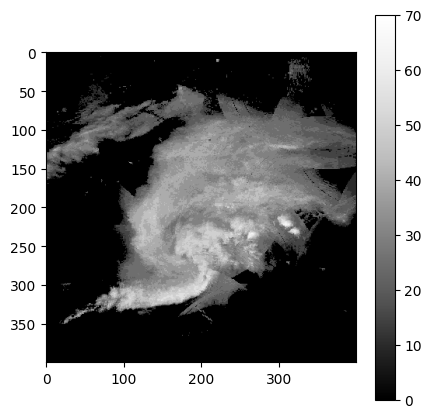

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 5,5

import cmweather
import numpy as np
from PIL import Image

radar_img = Image.open("BREF_090508_1300.png")
radar_img = np.array(radar_img)
radar_img = radar_img[600:1000, 1700:2100]

plt.imshow(radar_img*5, vmin=0, vmax=70, cmap='Greys_r')
plt.colorbar()

*Examine the histogram*

This gives us an initial idea of what threshold would work best. In this case, it seems somewhere between 10 and 55 would be an ideal split to get the most variance between groups:

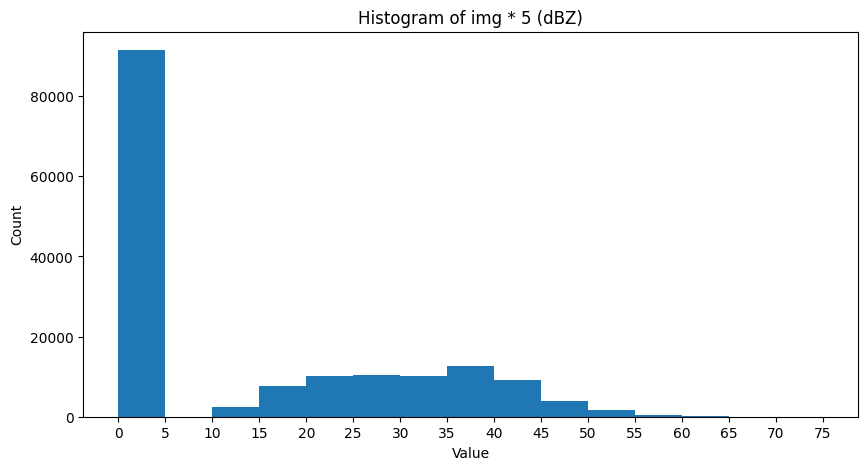

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Histogram counts and bin edges
count, bin_edges = np.histogram(radar_img * 5, bins=range(0, 80, 5))

plt.figure(figsize=(10, 5))
plt.bar(bin_edges[:-1], count, width=np.diff(bin_edges), align='edge')
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Histogram of img * 5 (dBZ)')
plt.xticks(bin_edges)
plt.show()

We can explicitly test this by looping through threshold candidates and testing the standard deviation of `foreground` and `background` pixels. We want to maximize the *between-group* variance.

We can create a function to calculate the between-group variance for one threshold:

In [4]:
def sigma_sq(image, threshold):

    background = image[image <= threshold]
    foreground = image[image > threshold]

    back_count = len(background)
    fore_count = len(foreground)

    if back_count == 0 or fore_count == 0:
        return 0

    total = back_count + fore_count

    back_frac = back_count / total
    fore_frac = fore_count / total

    back_mean = np.mean(background)
    fore_mean = np.mean(foreground)

    sigma_ = back_frac * fore_frac * (back_mean - fore_mean)**2

    return sigma_

And then we can run the loop and test each threshold. The highest variance is at 15 dBZ.

In [5]:
max_thresh = 60
min_thresh = 10
stride = 5

img_dbz = radar_img * 5

highest_var = -999
highest_thresh = min_thresh

for threshold in range(min_thresh, max_thresh + stride, stride):

    ssq = sigma_sq(img_dbz, threshold)

    if ssq > highest_var:
        highest_var = ssq
        highest_thresh = threshold

    message = (f"Threshold = {threshold:02d} \
                 sigma_sq = {ssq:.2f}")

    print(message)

print(f"\n\nWinning threshold = {highest_thresh:02d} (class variance = {highest_var:.2f})")

Threshold = 10                  sigma_sq = 212.63
Threshold = 15                  sigma_sq = 214.93
Threshold = 20                  sigma_sq = 205.51
Threshold = 25                  sigma_sq = 184.22
Threshold = 30                  sigma_sq = 151.71
Threshold = 35                  sigma_sq = 96.74
Threshold = 40                  sigma_sq = 47.85
Threshold = 45                  sigma_sq = 21.02
Threshold = 50                  sigma_sq = 5.25
Threshold = 55                  sigma_sq = 1.13
Threshold = 60                  sigma_sq = 0.30


Winning threshold = 15 (class variance = 214.93)


Finally, we can use this variance to define foreground and background pixels in the image:

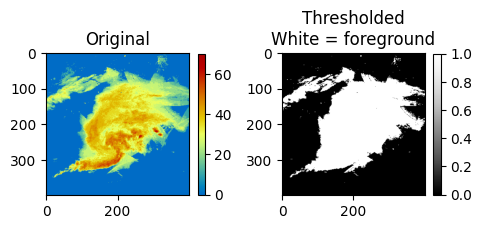

In [6]:
ax = plt.subplot(1, 2, 1)
ax.set_title("Original")
mmp = ax.imshow(img_dbz, cmap='HomeyerRainbow')
plt.colorbar(mmp, ax=ax, shrink=0.3)

ax = plt.subplot(1, 2, 2)
ax.set_title("Thresholded\nWhite = foreground")
mmp = ax.imshow(img_dbz > highest_thresh, cmap='Greys_r')
plt.colorbar(mmp, ax=ax, shrink=0.3)

plt.tight_layout()

We can also compare it to the built-in `threshold_otsu` from skimage:

In [7]:
from skimage.filters import threshold_otsu

threshold = threshold_otsu(img_dbz)

print(threshold)

15


**Manual thresholding**

While the `otsu` method has some utility, particularly when you do not know what threshold to use, it lacks some generalizability. Since it is data driven, the histogram of the image used to define the threshold may not be representative.

In many storm tracking applications, a threshold of 35 dBZ is a common choice for identifying thunderstorm rainfall rates vs. stratiform rainfall rates or no rainfall.

Use the widget below to apply various thresholds to the image. What threshold seems best for identifying the most intense (reds and orange) rainfall rates?

In [8]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

img_dbz = radar_img * 5

@interact(threshold=widgets.IntSlider(value=40, min=10, max=60, step=5))
def show_threshold(threshold):

    thresholded_image = img_dbz > threshold

    plt.figure(figsize=(7, 7))

    ax = plt.subplot(1, 2, 1)
    ax.set_title("Original\nPixels of interest circled in black", fontsize=10)
    mmp = ax.imshow(img_dbz, cmap='HomeyerRainbow')
    plt.colorbar(mmp, ax=ax, shrink=0.3)

    ax.contour(thresholded_image, boundaries=[1], colors=['k'])

    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=40, description='threshold', max=60, min=10, step=5), Output()), _dom_cl…

### Chapter 9.2.3 - Segmentation

The segmentation process uses the thresholded pixels as candidate pixels between which regions / blobs / objects can be created. The basic idea is that any "foreground" pixel could be a part of an object. Typically, "background" pixels are not considered. This can make the process of segmentation easier because objects are typically sparse within a larger image. In other words, only a small fraction of the original pixels should be foreground pixels.

One of the most popular segmentation approaches used in sklearn is `label` and is located at [`sklearn.measure.label`](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.label). This process connects activated pixels together to form contiguous groups. The user provides a thresholded image and a connection strategy that determines how a pixel is determined to be "touching" another pixel:

1. `connectivity=1`: the pixel only looks at the two pixels to the left and right (x dimension) and above and below (y dimension). In other words, pixels that touch its edges.

2. `connectivity=2`: the pixel looks at edges and diagonal touching.

The differences can be seen below using some sample data that only has diagonal neighbors (leftmost image).

If you use a connectivity of 1, each pixel will be its own cluster, which results in 9 clusters. If you pick a connectivity of 2, all of the pixels are associated with the same cluster.

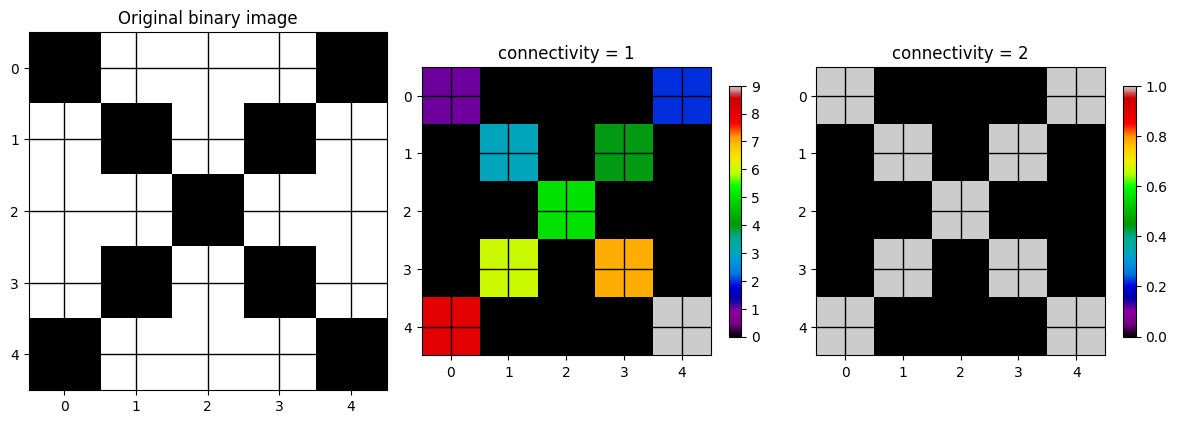

Number of objects with connectivity=1: 9
Number of objects with connectivity=2: 1


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label

# Binary image with diagonal touches
img = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1]
], dtype=np.uint8)

lab1 = label(img, connectivity=1)
lab2 = label(img, connectivity=2)

plt.figure(figsize=(12, 4))

ax = plt.subplot(1, 3, 1)
ax.imshow(img, cmap='gray_r')
ax.set_title("Original binary image")
ax.set_xticks(range(img.shape[1]))
ax.set_yticks(range(img.shape[0]))
ax.grid(color='k', linewidth=1)
ax.set_axisbelow(False)

ax = plt.subplot(1, 3, 2)
m1 = ax.imshow(lab1, cmap='nipy_spectral')
ax.set_title("connectivity = 1")
ax.set_xticks(range(img.shape[1]))
ax.set_yticks(range(img.shape[0]))
ax.grid(color='k', linewidth=1)
ax.set_axisbelow(False)
plt.colorbar(m1, ax=ax, shrink=0.7)

ax = plt.subplot(1, 3, 3)
m2 = ax.imshow(lab2, cmap='nipy_spectral')
ax.set_title("connectivity = 2")
ax.set_xticks(range(img.shape[1]))
ax.set_yticks(range(img.shape[0]))
ax.grid(color='k', linewidth=1)
ax.set_axisbelow(False)
plt.colorbar(m2, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

print("Number of objects with connectivity=1:", lab1.max())
print("Number of objects with connectivity=2:", lab2.max())

We can apply `label` to the radar image and modify the threshold and connectivity to see how that changes the segmentation result.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from skimage.measure import label

# Example image
img_dbz = radar_img * 5

threshold_slider = widgets.IntSlider(value=4, min=10, max=65, step=5, description='Threshold')
connectivity_dropdown = widgets.Dropdown(options=[1, 2], value=1, description='Connectivity')

out = widgets.Output()

def redraw(threshold, connectivity):
    with out:
        clear_output(wait=True)

        binary = img_dbz >= threshold
        labels = label(binary, connectivity=connectivity)
        n_objects = labels.max()

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        ax = axes[0]
        m0 = ax.imshow(img_dbz, cmap='HomeyerRainbow')
        ax.set_title("Original radar image")
        plt.colorbar(m0, ax=ax, shrink=0.3)

        ax = axes[1]
        ma_bin = np.ma.masked_where(binary==0, binary)
        m1 = ax.imshow(binary, cmap='Greys_r', vmin=0, vmax=1)
        ax.set_title(f"Thresholded\nthreshold = {threshold}")
        plt.colorbar(m1, ax=ax, shrink=0.3)

        ax = axes[2]
        vmax = max(1, n_objects)
        ma_lab = np.ma.masked_where(labels==0, labels)
        m2 = ax.imshow(ma_lab, cmap='nipy_spectral', vmin=0, vmax=vmax)
        ax.set_title(f"Labeled objects\nconnectivity = {connectivity}\nobjects = {n_objects}")
        plt.colorbar(m2, ax=ax, shrink=0.3)

        plt.tight_layout()
        plt.show()

widgets.interactive_output(
    redraw,
    {
        "threshold": threshold_slider,
        "connectivity": connectivity_dropdown
    }
)

display(widgets.HBox([threshold_slider, connectivity_dropdown]), out)

# draw initial state
redraw(threshold_slider.value, connectivity_dropdown.value)

Output()

### Chapter 9.2.4 - Watershed

The [Watershed](https://en.wikipedia.org/wiki/Watershed_(image_processing)) segmentation approach is another very popular approach in the Geosciences. It is based on the idea of geophysical watersheds which geologically define how drainage occurs in rivers and streams in an region. This approach defines regions by finding local maxima (or minima) that meet some initial threshold, and then building out the region until it reaches the secondary threshold by "flooding" the region. This approach is useful for when there are regions within a region that need to be distinct. For example, "thunderstorm cells" can be connected via pixel bridges, but are defined by their convective core where the most intense precipitation occurs.

The maximum extent region is typically defined using the thresholding step. The min/max of the basin is then given as an additional threshold to the watershed method or automatically identified using local min/max identification algorithms.

Below is `sklearn.segmentation.watershed` applied to the same image as above. You can see that within regions that were connected above, there are now distinct sub-regions. The distance transform image is a representation of how far a pixel is from the closest basin center. You can see how it looks like topography. Pixels will "drain" away from the max values in the distance transform (mountain peaks) to the basins (valleys). Pixels on either side then "belong" to the respective basins.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

img_dbz = radar_img * 5

threshold_slider = widgets.IntSlider(
    value=10, min=10, max=65, step=5, description='Threshold'
)

connectivity_dropdown = widgets.Dropdown(
    options=[1, 2], value=1, description='Connectivity'
)

out = widgets.Output()

def redraw(threshold, connectivity):
    with out:
        clear_output(wait=True)

        binary = img_dbz >= threshold

        distance = ndi.distance_transform_edt(binary)

        coords = peak_local_max(
            distance,
            footprint=np.ones((3, 3)),
            labels=binary
        )

        markers = np.zeros(binary.shape, dtype=int)
        for i, (r, c) in enumerate(coords, start=1):
            markers[r, c] = i

        markers = ndi.label(markers > 0, structure=ndi.generate_binary_structure(2, connectivity))[0]

        labels = watershed(-distance, markers, mask=binary)
        n_objects = labels.max()

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))

        ax = axes[0]
        m0 = ax.imshow(img_dbz, cmap='jet')
        ax.set_title("Original radar image")
        plt.colorbar(m0, ax=ax, shrink=0.3)

        ax = axes[1]
        m1 = ax.imshow(binary, cmap='Greys_r', vmin=0, vmax=1)
        ax.set_title(f"Thresholded\nthreshold = {threshold}")
        plt.colorbar(m1, ax=ax, shrink=0.3)

        ax = axes[2]
        m2 = ax.imshow(distance, cmap='viridis')
        ax.set_title("Distance transform")
        plt.colorbar(m2, ax=ax, shrink=0.3)

        ax = axes[3]
        vmax = max(1, n_objects)
        m3 = ax.imshow(labels, cmap='nipy_spectral', vmin=0, vmax=vmax)
        ax.set_title(f"Watershed labels\nconnectivity = {connectivity}\nobjects = {n_objects}")
        plt.colorbar(m3, ax=ax, shrink=0.3)

        plt.tight_layout()
        plt.show()

widgets.interactive_output(
    redraw,
    {
        "threshold": threshold_slider,
        "connectivity": connectivity_dropdown
    }
)

display(widgets.HBox([threshold_slider, connectivity_dropdown]), out)

redraw(threshold_slider.value, connectivity_dropdown.value)

Output()

*Try it yourself*

Bring in a gridded dataset from your term project and see if you can apply one of the segmentation approaches demonstrated above. What challenges did you encounter? Subjectively, did it do a good job? Is there some value?